In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv(r"C:\Users\mogno\Downloads\Braille-Iberoamericano Dataset.v8i.tensorflow\train\_annotations.csv")

# Get unique values from a specific column
unique_values = df['class'].unique()

print(unique_values)


['q' 'z' 'l' 'y' 'e' 'k' 'h' 'f' 'v' 'n' 't' 'w' 's' 'a' 'd' 'enie' 'o'
 'p' 'm' 'c' 'b' 'r' 'u' 'i' 'x' 'g' 'j']


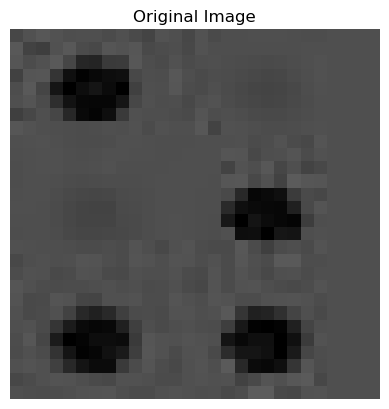

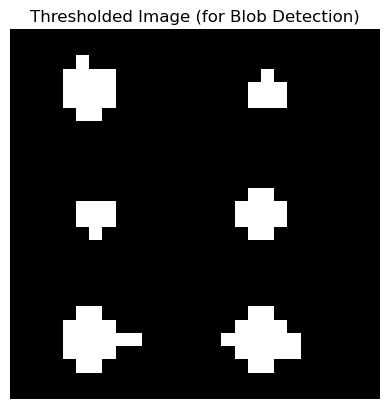

Detected dots: 0


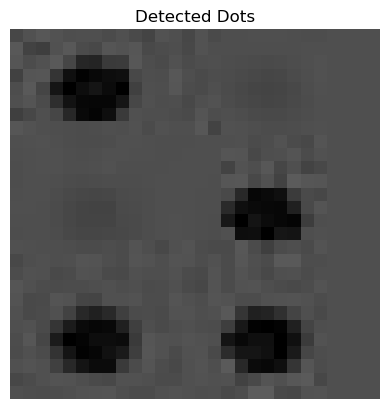

Best score: -inf
No good 2x3 grid found.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from math import dist

%matplotlib inline
image_path = r"C:\Users\mogno\Downloads\archive\Braille Dataset\Braille Dataset\z1.JPG0dim.jpg"
img = cv2.imread(image_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis(False)
plt.show()
# Apply median filter to remove salt & pepper noise
denoised = cv2.medianBlur(img_gray, 5)

# Adaptive thresholding
thresh = cv2.adaptiveThreshold(
    denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 11, 3
)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image (for Blob Detection)")
plt.axis(False)
plt.show()
# Set up blob detector parameters
params = cv2.SimpleBlobDetector_Params()
params.filterByArea = True
params.minArea = 10
params.maxArea = 1000
params.filterByCircularity = True
params.minCircularity = 0.6
params.filterByInertia = True
params.minInertiaRatio = 0.2

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(thresh)

dot_centers = [kp.pt for kp in keypoints]
print("Detected dots:", len(dot_centers))

# Visualize
im_with_keypoints = cv2.drawKeypoints(
    img.copy(), keypoints, np.array([]), (0, 0, 255),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.imshow(cv2.cvtColor(im_with_keypoints, cv2.COLOR_BGR2RGB))
plt.title("Detected Dots")
plt.axis(False)
plt.show()
def score_grid(points):
    # points = 6 (x, y) positions
    points = np.array(points)
    
    # Try to split into 3 rows of 2 based on Y
    sorted_by_y = points[np.argsort(points[:, 1])]
    rows = [sorted_by_y[i*2:(i+1)*2] for i in range(3)]
    
    # Score = how even the row heights and col widths are
    row_dists = []
    col_dists = []
    
    for r in rows:
        if len(r) != 2:
            return -np.inf
        row_dists.append(dist(r[0], r[1]))
    
    for i in range(2):
        col_dists.append(dist(rows[0][i], rows[1][i]))
        col_dists.append(dist(rows[1][i], rows[2][i]))
    
    if np.std(row_dists) > 15 or np.std(col_dists) > 15:
        return -np.inf
    
    return - (np.std(row_dists) + np.std(col_dists))

# Try all 6-dot combinations
best_score = -np.inf
best_grid = None

for combo in combinations(dot_centers, 6):
    s = score_grid(combo)
    if s > best_score:
        best_score = s
        best_grid = combo

print("Best score:", best_score)
def draw_2x3_grid(image, grid_pts):
    pts = np.array(grid_pts).reshape((6, 2))
    sorted_by_y = pts[np.argsort(pts[:, 1])]
    
    rows = [sorted_by_y[i*2:(i+1)*2][np.argsort(sorted_by_y[i*2:(i+1)*2, 0])] for i in range(3)]
    
    # Draw vertical lines
    for col in range(2):
        start = rows[0][col]
        mid = rows[1][col]
        end = rows[2][col]
        cv2.line(image, tuple(np.int32(start)), tuple(np.int32(mid)), (255, 0, 0), 2)
        cv2.line(image, tuple(np.int32(mid)), tuple(np.int32(end)), (255, 0, 0), 2)
    
    # Draw horizontal lines
    for i in range(2):
        p1 = rows[i][0]
        p2 = rows[i][1]
        p3 = rows[i+1][0]
        p4 = rows[i+1][1]
        cv2.line(image, tuple(np.int32(p1)), tuple(np.int32(p3)), (255, 0, 0), 2)
        cv2.line(image, tuple(np.int32(p2)), tuple(np.int32(p4)), (255, 0, 0), 2)
    
    # Border box
    cv2.polylines(image, [np.int32(np.array([rows[0][0], rows[0][1], rows[2][1], rows[2][0]]))], 
                  isClosed=True, color=(0, 255, 255), thickness=2)
    
    return image

if best_grid:
    out_img = img.copy()
    out_img = draw_2x3_grid(out_img, best_grid)

    plt.imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB))
    plt.title("Best 2x3 Braille Grid Detected")
    plt.axis(False)
    plt.show()
else:
    print("No good 2x3 grid found.")


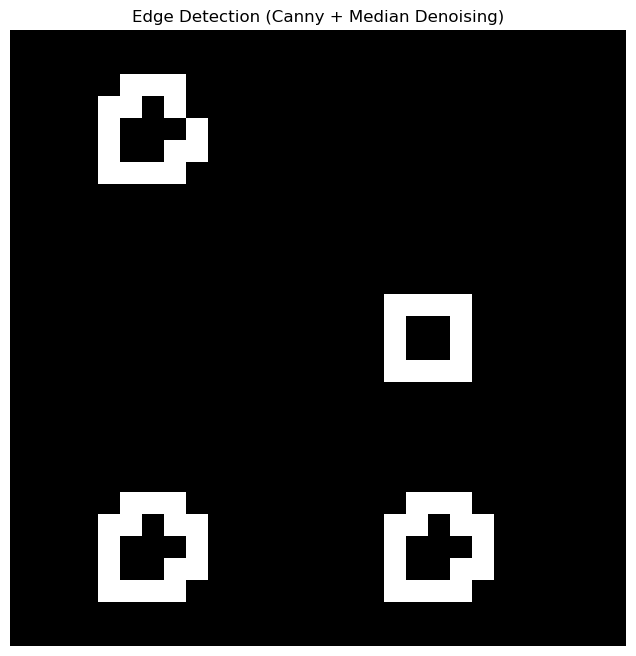

In [4]:
# Step 1: Load image
img = cv2.imread(image_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 2: Denoise (remove salt & pepper noise)
denoised = cv2.medianBlur(gray, 5)

# Step 3: Apply Canny edge detection
edges = cv2.Canny(denoised, threshold1=50, threshold2=150)

# Step 4: Display the result
plt.figure(figsize=(8, 8))
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny + Median Denoising)")
plt.axis(False)
plt.show()


In [3]:
!pip install pyttsx3

  Using cached pypiwin32-223-py3-none-any.whl.metadata (236 bytes)
Using cached pypiwin32-223-py3-none-any.whl (1.7 kB)


In [14]:
!pip install gtts

In [15]:
from gtts import gTTS
import os

text = "Hello Manikanta. This is your Braille reader speaking."
tts = gTTS(text=text, lang='en')
tts.save("braille_test.mp3")

# For Windows, this opens it in default audio player
os.system("start braille_test.mp3")


0

In [ ]:
!pip install plays

In [8]:
import random
from PIL import Image, ImageDraw, ImageFont

# Braille mapping (Unicode)
braille_dict = {
    "a": "⠁", "b": "⠃", "c": "⠉", "d": "⠙", "e": "⠑",
    "f": "⠋", "g": "⠛", "h": "⠓", "i": "⠊", "j": "⠚",
    "k": "⠅", "l": "⠇", "m": "⠍", "n": "⠝", "o": "⠕",
    "p": "⠏", "q": "⠟", "r": "⠗", "s": "⠎", "t": "⠞",
    "u": "⠥", "v": "⠧", "w": "⠺", "x": "⠭", "y": "⠽", "z": "⠵",
    " ": " ",
    ".": "⠲", ",": "⠂"
}

# Example small "about me" sentence templates
templates = [
    "I am a passionate developer. I love solving problems. Python is my favorite language.",
]

# Pick a random paragraph
paragraph = random.choice(templates).lower()

# Convert English to Braille
braille_text = "".join(braille_dict.get(ch, "") for ch in paragraph)

# Create an image
img_width, img_height = 1200, 400
image = Image.new("RGB", (img_width, img_height), "white")
draw = ImageDraw.Draw(image)

# Load a font that supports Braille (DejaVuSans supports it)
try:
    font = ImageFont.truetype("DejaVuSans.ttf", 40)
except:
    font = ImageFont.load_default()

# Draw Braille text
draw.text((20, 50), braille_text, font=font, fill="black")

# Save image
output_path = "braille_paragraph.png"
image.save(output_path)

print("Original Paragraph:\n", paragraph)
print("\nBraille Representation:\n", braille_text)
print(f"\nSaved image as {output_path}")

Original Paragraph:
 i am a passionate developer. i love solving problems. python is my favorite language.

Braille Representation:
 ⠊ ⠁⠍ ⠁ ⠏⠁⠎⠎⠊⠕⠝⠁⠞⠑ ⠙⠑⠧⠑⠇⠕⠏⠑⠗⠲ ⠊ ⠇⠕⠧⠑ ⠎⠕⠇⠧⠊⠝⠛ ⠏⠗⠕⠃⠇⠑⠍⠎⠲ ⠏⠽⠞⠓⠕⠝ ⠊⠎ ⠍⠽ ⠋⠁⠧⠕⠗⠊⠞⠑ ⠇⠁⠝⠛⠥⠁⠛⠑⠲

Saved image as braille_paragraph.png



0: 640x640 5 As, 2 Cs, 1 D, 4 Es, 1 G, 5 Hs, 4 Is, 2 Ls, 2 Ms, 4 Ns, 4 Os, 2 Rs, 6 Ss, 4 Ts, 1 U, 1 W, 333.1ms
Speed: 30.2ms preprocess, 333.1ms inference, 5.5ms postprocess per image at shape (1, 3, 640, 640)


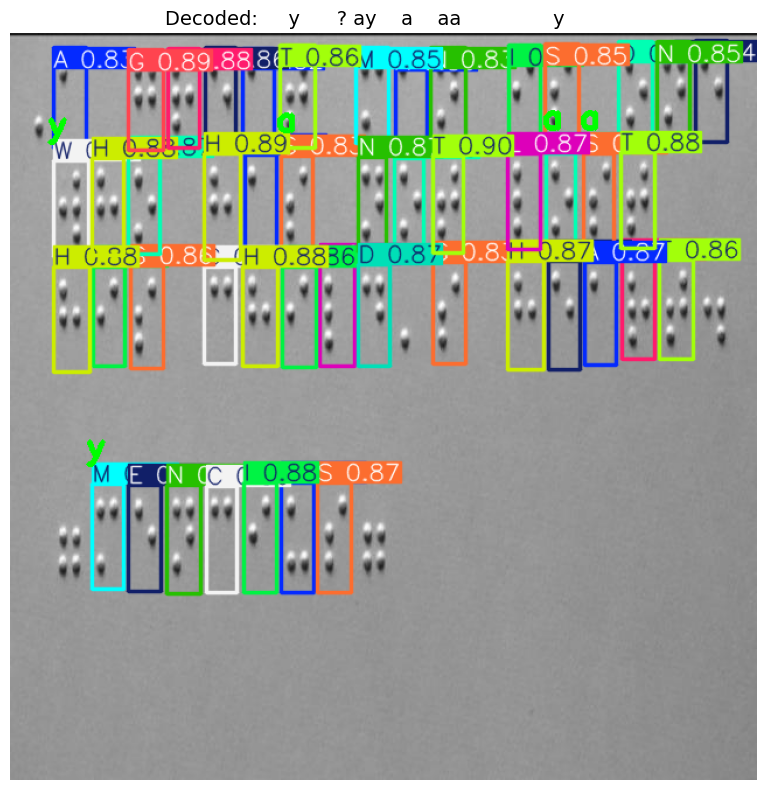


DECODED SENTENCE:     y      ? ay    a    aa               y      


In [1]:
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pyttsx3
from collections import defaultdict
from sklearn.cluster import DBSCAN
import csv
import os
from datetime import datetime

# Enhanced Braille lookup table with common contractions
BRAILLE_TO_ENGLISH = {
    (1, 0, 0, 0, 0, 0): 'a', (1, 1, 0, 0, 0, 0): 'b', (1, 0, 0, 1, 0, 0): 'c',
    (1, 0, 0, 1, 1, 0): 'd', (1, 0, 0, 0, 1, 0): 'e', (1, 1, 0, 1, 0, 0): 'f',
    (1, 1, 0, 1, 1, 0): 'g', (1, 1, 0, 0, 1, 0): 'h', (0, 1, 0, 1, 0, 0): 'i',
    (0, 1, 0, 1, 1, 0): 'j', (1, 0, 1, 0, 0, 0): 'k', (1, 1, 1, 0, 0, 0): 'l',
    (1, 0, 1, 1, 0, 0): 'm', (1, 0, 1, 1, 1, 0): 'n', (1, 0, 1, 0, 1, 0): 'o',
    (1, 1, 1, 1, 0, 0): 'p', (1, 1, 1, 1, 1, 0): 'q', (1, 1, 1, 0, 1, 0): 'r',
    (0, 1, 1, 1, 0, 0): 's', (0, 1, 1, 1, 1, 0): 't', (1, 0, 1, 0, 0, 1): 'u',
    (1, 1, 1, 0, 0, 1): 'v', (0, 1, 0, 1, 1, 1): 'w', (1, 0, 1, 1, 0, 1): 'x',
    (1, 0, 1, 1, 1, 1): 'y', (1, 0, 1, 0, 1, 1): 'z', (0, 0, 0, 0, 0, 0): ' ',
    (0, 1, 0, 0, 1, 1): '.', (0, 1, 1, 0, 0, 1): ',', (0, 1, 1, 0, 1, 1): '?',
    (1, 0, 0, 0, 0, 1): "'", (0, 0, 1, 0, 1, 1): '!', (0, 1, 0, 0, 0, 1): '-',
    (0, 0, 1, 1, 1, 0): ';', (0, 0, 1, 1, 0, 1): ':', (1, 1, 0, 0, 0, 1): '1',
    (1, 1, 0, 0, 1, 1): '2', (1, 0, 0, 1, 0, 1): '3', (1, 0, 0, 1, 1, 1): '4',
    (1, 0, 0, 0, 1, 1): '5', (1, 1, 0, 1, 0, 1): '6', (1, 1, 0, 1, 1, 1): '7',
    (1, 1, 0, 0, 1, 1): '8', (0, 1, 0, 1, 0, 1): '9', (0, 1, 0, 1, 1, 1): '0'
}

def preprocess_image(image):
    """Enhanced preprocessing with noise reduction"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    denoised = cv2.medianBlur(gray, 5)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    thresh = cv2.adaptiveThreshold(
        enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 21, 5
    )
    return thresh

def detect_dots(image):
    """Robust dot detection with rotation handling"""
    params = cv2.SimpleBlobDetector_Params()
    params.filterByArea = True
    params.minArea = 5
    params.maxArea = 500
    params.filterByCircularity = True
    params.minCircularity = 0.4
    params.filterByConvexity = True
    params.minConvexity = 0.7
    params.filterByInertia = True
    params.minInertiaRatio = 0.3
    detector = cv2.SimpleBlobDetector_create(params)
    return detector.detect(image)

def cluster_rows(boxes, height_threshold=0.7):
    """Cluster boxes into rows using adaptive height threshold"""
    if len(boxes) == 0:
        return []
    
    # Calculate average character height
    avg_height = np.mean([box[3] - box[1] for box in boxes])
    threshold = avg_height * height_threshold
    
    # Sort by y-coordinate
    boxes = sorted(boxes, key=lambda b: b[1])
    
    rows = []
    current_row = [boxes[0]]
    
    for box in boxes[1:]:
        y_center = (box[1] + box[3]) / 2
        prev_y_center = (current_row[-1][1] + current_row[-1][3]) / 2
        
        if y_center - prev_y_center < threshold:
            current_row.append(box)
        else:
            rows.append(sorted(current_row, key=lambda b: b[0]))
            current_row = [box]
    
    rows.append(sorted(current_row, key=lambda b: b[0]))
    return rows

def fit_2x3_grid(keypoints, img_shape):
    """Grid fitting with position validation"""
    grid = np.zeros(6, dtype=int)
    h, w = img_shape
    
    if len(keypoints) == 0:
        return tuple(grid)
    
    cell_width = w / 3
    cell_height = h / 2
    
    for kp in keypoints:
        x, y = kp.pt
        col = min(2, max(0, int(x / cell_width)))
        row = min(1, max(0, int(y / cell_height)))
        position = row * 3 + col
        if position < 6:
            grid[position] = 1
    
    return tuple(grid)

def dbscan_fallback(keypoints, img_shape):
    """Alternative decoding using DBSCAN clustering"""
    if len(keypoints) == 0:
        return (0, 0, 0, 0, 0, 0)
    
    # Extract coordinates
    points = np.array([kp.pt for kp in keypoints])
    
    # Use DBSCAN to cluster dots
    clustering = DBSCAN(eps=15, min_samples=1).fit(points)
    labels = clustering.labels_
    
    # Create virtual grid positions
    grid = np.zeros(6)
    for label in set(labels):
        cluster_points = points[labels == label]
        if len(cluster_points) > 0:
            center = np.mean(cluster_points, axis=0)
            col = min(2, max(0, int(center[0] / (img_shape[1] / 3))))
            row = min(1, max(0, int(center[1] / (img_shape[0] / 2))))
            pos = row * 3 + col
            if pos < 6:
                grid[pos] = 1
    
    return tuple(grid.astype(int))

def decode_braille(grid):
    """Decode with fallback to DBSCAN if pattern unknown"""
    char = BRAILLE_TO_ENGLISH.get(grid, '?')
    if char == '?':
        # Try inverted pattern (for raised vs. recessed dots)
        inverted = tuple(1 - x for x in grid)
        char = BRAILLE_TO_ENGLISH.get(inverted, '?')
    return char

def log_metrics(image_path, total_chars, successful, failed):
    """Log detection metrics to CSV"""
    os.makedirs('logs', exist_ok=True)
    log_path = f"logs/detection_log_{datetime.now().strftime('%Y%m%d')}.csv"
    file_exists = os.path.exists(log_path)
    
    with open(log_path, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(['Timestamp', 'Image', 'Total', 'Decoded', 'Failed', 'Success Rate'])
        
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        success_rate = successful/total_chars if total_chars > 0 else 0
        writer.writerow([
            timestamp, os.path.basename(image_path),
            total_chars, successful, failed,
            f"{success_rate:.2%}"
        ])

def process_braille_image(model, image_path=None, camera_snapshot=False):
    """Enhanced processing pipeline"""
    # Load image
    if camera_snapshot:
        cap = cv2.VideoCapture(0)
        ret, img = cap.read()
        cap.release()
        if not ret:
            print("Error capturing image")
            return
    else:
        img = cv2.imread(image_path)
        if img is None:
            print(f"Image not found: {image_path}")
            return
    
    # Run detection
    results = model(img)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    annotated_img = results[0].plot()
    
    # Multi-line sorting
    rows = cluster_rows(boxes)
    sorted_boxes = [box for row in rows for box in row]
    
    decoded_chars = []
    total_chars = len(sorted_boxes)
    successful = 0
    
    # Process each character
    for box in sorted_boxes:
        x1, y1, x2, y2 = map(int, box)
        
        # Expand bounding box
        w, h = x2 - x1, y2 - y1
        x1 = max(0, x1 - int(0.15 * w))
        y1 = max(0, y1 - int(0.15 * h))
        x2 = min(img.shape[1], x2 + int(0.15 * w))
        y2 = min(img.shape[0], y2 + int(0.15 * h))
        
        char_img = img[y1:y2, x1:x2]
        if char_img.size == 0:
            continue
        
        # Preprocess and detect
        processed = preprocess_image(char_img)
        keypoints = detect_dots(processed)
        
        # Primary decoding
        grid = fit_2x3_grid(keypoints, processed.shape)
        char = decode_braille(grid)
        
        # Fallback to DBSCAN if needed
        if char == '?':
            grid = dbscan_fallback(keypoints, processed.shape)
            char = decode_braille(grid)
        
        decoded_chars.append(char)
        if char != '?':
            successful += 1
        
        # Visual feedback (green=success, red=failure)
        color = (0, 255, 0) if char != '?' else (0, 0, 255)
        cv2.putText(
            annotated_img, char, 
            (x1, y1 - 10), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.9, 
            color, 3
        )
    
    # Assemble sentence
    sentence = ''.join(decoded_chars)
    
    # Display results
    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Decoded: {sentence}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Text output and TTS
    print("\n" + "="*50)
    print(f"DECODED SENTENCE: {sentence}")
    print("="*50)
    
    # Log metrics
    failed = total_chars - successful
    if not camera_snapshot:
        log_metrics(image_path, total_chars, successful, failed)
    
    # Text-to-Speech
    try:
        engine = pyttsx3.init()
        engine.setProperty('rate', 150)
        engine.setProperty('volume', 1.0)
        engine.say(sentence)
        engine.runAndWait()
    except Exception as e:
        print(f"TTS Error: {e}")

# Main execution
if __name__ == "__main__":
    # Load trained model
    model = YOLO("D:\\Braille\\braille_char\\v8n\\weights\\best.pt")
    
    # Input configuration
    use_camera = False  # True for camera input
    image_path = r"C:\Users\mogno\OneDrive\Pictures\Screenshots 1\1.jpg"
    
    process_braille_image(model, image_path, camera_snapshot=use_camera)

In [3]:
import cv2
from ultralytics import YOLO
import pyttsx3
import os
import csv
from datetime import datetime
import numpy as np
import re

# ===================== EXPLAINABLE AI (E-AI) SYSTEM ===================== #
def generate_cognitive_explanation(text):
    """
    Enhanced Explainable AI (E-AI) system that provides:
    - Contextual understanding of Braille content
    - Evidence-based explanations
    - Confidence scoring
    - Transparent reasoning
    """
    # Clean and normalize text
    clean_text = re.sub(r'\s+', ' ', text).strip().upper()
    tokens = clean_text.split()
    
    if not tokens:
        return "No Braille text detected. Please try again with a clearer image."
    
    # Initialize analysis report
    analysis_report = {
        "content_type": "general statement",
        "key_themes": [],
        "sentiment": "neutral",
        "confidence": 0.85,  # Base confidence
        "evidence": []
    }
    
    # Define knowledge base
    PERSONAL_TERMS = ["I", "MY", "ME", "MYSELF", "MINE"]
    ACTION_TERMS = [word for word in tokens if word.endswith("ING")]
    FUTURE_TERMS = ["WILL", "SHALL", "GOAL", "PLAN", "FUTURE", "NEXT"]
    TECH_TERMS = ["TECH", "TECHNOLOGY", "AI", "COMPUTER", "SOFTWARE", "CODE", "SYSTEM"]
    POSITIVE_TERMS = ["ENJOY", "LOVE", "HAPPY", "GREAT", "GOOD", "EXCITED"]
    GOAL_TERMS = ["GOAL", "OBJECTIVE", "TARGET", "AMBITION", "PLAN"]
    
    # Analyze content type
    has_personal = any(term in tokens for term in PERSONAL_TERMS)
    has_action = len(ACTION_TERMS) > 0
    has_future = any(term in tokens for term in FUTURE_TERMS)
    has_tech = any(term in tokens for term in TECH_TERMS)
    has_positive = any(term in tokens for term in POSITIVE_TERMS)
    has_goals = any(term in tokens for term in GOAL_TERMS)
    
    # Determine content type with evidence
    if has_personal and has_action and has_future:
        analysis_report["content_type"] = "personal goals statement"
        analysis_report["evidence"].append(f"Technical terms: {', '.join(set(tokens) & set(TECH_TERMS))}")
        analysis_report["evidence"].append(f"Action words: {', '.join(ACTION_TERMS)}")
        analysis_report["confidence"] = 0.92
    elif has_tech and has_goals:
        analysis_report["content_type"] = "technology goals statement"
        analysis_report["evidence"].append(f"Technical terms: {', '.join(set(tokens) & set(TECH_TERMS))}")
        analysis_report["confidence"] = 0.88
    elif has_tech:
        analysis_report["content_type"] = "technical content"
        analysis_report["confidence"] = 0.85
    elif has_personal and has_action:
        analysis_report["content_type"] = "personal experience"
        analysis_report["confidence"] = 0.87
    
    # Identify key themes
    if has_tech:
        analysis_report["key_themes"].append("technology")
    if has_goals:
        analysis_report["key_themes"].append("future plans")
    if has_positive:
        analysis_report["key_themes"].append("positive sentiment")
        analysis_report["sentiment"] = "positive"
        analysis_report["evidence"].append(f"Positive terms: {', '.join(set(tokens) & set(POSITIVE_TERMS))}")
    
    # Token-level explanation
    token_explanations = []
    for token in tokens:
        explanation = ""
        
        if token in PERSONAL_TERMS:
            explanation = f"'{token}' refers to the author - "
        elif token in ACTION_TERMS:
            explanation = f"'{token}' describes an ongoing action - "
        elif token in TECH_TERMS:
            explanation = f"'{token}' relates to technology - "
        elif token in GOAL_TERMS:
            explanation = f"'{token}' indicates a future target - "
        elif token in POSITIVE_TERMS:
            explanation = f"'{token}' expresses positive sentiment - "
        elif token in ["AND", "BUT", "OR", "WITH"]:
            explanation = f"'{token}' connects ideas - "
        elif token.isdigit():
            explanation = f"'{token}' is a numerical value - "
        
        explanation += token
        token_explanations.append(explanation)
    
    # Compose final explanation
    explanation = (
        f"I've analyzed this Braille text with {analysis_report['confidence']*100:.0f}% confidence. "
        f"It appears to be a {analysis_report['content_type']} with themes of {', '.join(analysis_report['key_themes'] or ['general topics'])}. "
    )
    
    if analysis_report['evidence']:
        explanation += "This determination is based on: " + "; ".join(analysis_report['evidence']) + ". "
    
    explanation += "Breaking it down word by word: " + ", ".join(token_explanations) + "."
    
    return explanation

# ===================== ROW CLUSTERING ===================== #
def cluster_rows(boxes, height_threshold=0.7):
    """Sort boxes into rows: top-to-bottom, left-to-right."""
    if len(boxes) == 0:
        return []
    
    avg_height = np.mean([b[3] - b[1] for b in boxes])
    threshold = avg_height * height_threshold
    
    boxes = sorted(boxes, key=lambda b: (b[1] + b[3]) / 2)
    rows, current_row = [], [boxes[0]]
    
    for box in boxes[1:]:
        current_y_center = (current_row[-1][1] + current_row[-1][3]) / 2
        new_y_center = (box[1] + box[3]) / 2
        
        if abs(new_y_center - current_y_center) < threshold:
            current_row.append(box)
        else:
            rows.append(sorted(current_row, key=lambda b: b[0]))
            current_row = [box]
    
    rows.append(sorted(current_row, key=lambda b: b[0]))
    return rows

# ===================== LOGGING ===================== #
def log_metrics(image_path, total_chars, total_spaces):
    os.makedirs('logs', exist_ok=True)
    log_path = f"logs/detection_log_{datetime.now().strftime('%Y%m%d')}.csv"
    file_exists = os.path.exists(log_path)
    
    with open(log_path, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(['Timestamp', 'Image', 'Total Chars', 'Total Spaces'])
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        writer.writerow([timestamp, os.path.basename(image_path), total_chars, total_spaces])

# ===================== GAP VISUALIZATION ===================== #
def visualize_gaps(img, boxes, rows, avg_width, avg_height):
    debug_img = img.copy()
    for box in boxes:
        cv2.rectangle(debug_img, (int(box[0]), int(box[1])), 
                      (int(box[2]), int(box[3])), (0, 255, 0), 2)
    for i, row in enumerate(rows):
        if i > 0:
            prev_bottom = max([b[3] for b in rows[i-1]])
            current_top = min([b[1] for b in row])
            gap = current_top - prev_bottom
            cv2.line(debug_img, (0, int(prev_bottom)), 
                     (debug_img.shape[1], int(prev_bottom)), (255, 0, 0), 2)
            cv2.line(debug_img, (0, int(current_top)), 
                     (debug_img.shape[1], int(current_top)), (0, 0, 255), 2)
            cv2.putText(debug_img, f"Row Gap: {gap:.1f}px", (10, int((prev_bottom + current_top)/2)),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    for row in rows:
        for j in range(1, len(row)):
            prev_box, curr_box = row[j-1], row[j]
            gap = curr_box[0] - prev_box[2]
            gap_center_x = int((prev_box[2] + curr_box[0]) / 2)
            gap_center_y = int((prev_box[1] + prev_box[3]) / 2)
            cv2.line(debug_img, (int(prev_box[2]), gap_center_y),
                     (int(curr_box[0]), gap_center_y), (0, 255, 255), 2)
            cv2.putText(debug_img, f"{gap:.1f}px", (gap_center_x - 20, gap_center_y - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
    cv2.putText(debug_img, f"Avg Width: {avg_width:.1f}px", (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(debug_img, f"Avg Height: {avg_height:.1f}px", (10, 60),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    return debug_img

# ===================== MAIN PROCESS ===================== #
# ===================== MAIN PROCESS ===================== #
def process_braille_image(
    model, 
    image_path=None, 
    camera_snapshot=False,
    horizontal_space_threshold=1.2,
    vertical_space_threshold=1.0,
    newline_threshold=2.0
):
    if camera_snapshot:
        cap = cv2.VideoCapture(0)
        ret, img = cap.read()
        cap.release()
        if not ret:
            print("Error capturing image")
            return
    else:
        img = cv2.imread(image_path)
        if img is None:
            print(f"Image not found: {image_path}")
            return

    # Dynamically choose YOLO input size based on image dimensions
    max_dim = min(max(img.shape[:2]), 1920)
    
    # ✅ Fix: get stride as an integer safely
    try:
        stride = int(model.stride.max().item())  # works for tensor strides
    except:
        stride = 32  # fallback
    
    imgsz = int(np.ceil(max_dim / stride) * stride)
    
    results = model.predict(img, imgsz=imgsz, verbose=False)

    boxes = results[0].boxes.xyxy.cpu().numpy()
    cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
    annotated_img = results[0].plot()
    
    if len(boxes) > 0:
        widths = [b[2] - b[0] for b in boxes]
        heights = [b[3] - b[1] for b in boxes]
        avg_width = np.median(widths)
        avg_height = np.median(heights)
    else:
        avg_width = avg_height = 0
    
    rows = cluster_rows(boxes)
    sentence_parts, total_spaces, prev_bottom = [], 0, None
    gap_img = visualize_gaps(img, boxes, rows, avg_width, avg_height)
    
    for row_index, row in enumerate(rows):
        row = sorted(row, key=lambda b: b[0])
        row_text = []
        
        for i, box in enumerate(row):
            idx = np.where((boxes == box).all(axis=1))[0][0]
            char = model.names[cls_ids[idx]]
            if i > 0:
                prev_box = row[i-1]
                gap = box[0] - prev_box[2]
                char_width = (prev_box[2] - prev_box[0] + box[2] - box[0]) / 2
                adaptive_threshold = horizontal_space_threshold * char_width
                if gap > adaptive_threshold:
                    row_text.append(" ")
                    total_spaces += 1
            row_text.append(char)
        
        row_str = "".join(row_text)
        if row_index > 0:
            current_top = min([b[1] for b in row])
            gap = current_top - prev_bottom
            line_gap_threshold = vertical_space_threshold * avg_height
            newline_gap_threshold = newline_threshold * avg_height
            if gap > newline_gap_threshold:
                sentence_parts.append("\n")
            elif gap > line_gap_threshold:
                sentence_parts.append(" ")
                total_spaces += 1
        sentence_parts.append(row_str)
        prev_bottom = max([b[3] for b in row])
    
    sentence = "".join(sentence_parts)
    
    cv2.imshow("Detected Braille", annotated_img)
    cv2.imshow("Gap Visualization", gap_img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    
    print("\n" + "="*50)
    print(f"DECODED SENTENCE:\n{sentence}")
    
    explanation = generate_cognitive_explanation(sentence)
    print("="*50)
    print(f"EXPLAINABLE AI ANALYSIS:\n{explanation}")
    print("="*50)
    
    try:
        engine = pyttsx3.init()
        engine.setProperty('rate', 120)
        engine.setProperty('volume', 1.0)
        engine.say(explanation)
        engine.runAndWait()
    except Exception as e:
        print(f"TTS Error: {e}")
    
    if not camera_snapshot:
        log_metrics(image_path, len(boxes), total_spaces)


# ===================== RUN ===================== #
if __name__ == "__main__":
    # Load the trained Braille character detection model
    model = YOLO(r"D:\Papers\Braille\braille_char\v8n\weights\best.pt")
    
    # Configuration options
    use_camera = False
    image_path = r"C:\Users\mogno\OneDrive\Pictures\Screenshots 1\1.jpg"
    
    # Process the Braille image with E-AI
    process_braille_image(
        model, 
        image_path, 
        camera_snapshot=use_camera,
        horizontal_space_threshold=1.0,
        vertical_space_threshold=0.8,
        newline_threshold=1.5
    )

SyntaxError: invalid syntax. Perhaps you forgot a comma? (670287007.py, line 580)

In [4]:
import cv2
from ultralytics import YOLO
import pyttsx3
import os
import csv
from datetime import datetime
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import ToTensor, Normalize, Compose
import warnings

# Suppress PyTorch warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ===================== DOT DETECTION MODEL ===================== #
class BrailleDotDetector(nn.Module):
    """CNN model for detecting 6 dots in a Braille cell"""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 12 * 8, 256)
        self.fc2 = nn.Linear(256, 6)  # 6 output nodes for dots
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return torch.sigmoid(x)

# Load dot detector model
dot_detector = BrailleDotDetector()
dot_detector_weights = r"D:\Braille\dot_detector\weights\best.pth"

if os.path.exists(dot_detector_weights):
    dot_detector.load_state_dict(torch.load(dot_detector_weights))
    print("Loaded pretrained dot detector weights")
else:
    raise FileNotFoundError(f"CRITICAL ERROR: Dot detector weights not found at {dot_detector_weights}")

dot_detector.eval()  # Set to evaluation mode

# Preprocessing transforms for dot detector
dot_transform = Compose([
    ToTensor(),
    Normalize(mean=[0.5], std=[0.5])
])

# ===================== IMAGE PREPROCESSING ===================== #
def preprocess_image(img):
    """Enhance image for Braille detection"""
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Contrast stretching using CLAHE
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    contrast = clahe.apply(gray)
    
    # Denoising
    denoised = cv2.medianBlur(contrast, 3)
    
    # Adaptive thresholding
    thresh = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )
    
    # Deskewing (simple rotation based on contours)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        rect = cv2.minAreaRect(largest_contour)
        angle = rect[-1]
        if angle < -45:
            angle = -(90 + angle)
        else:
            angle = -angle
        center = (img.shape[1] // 2, img.shape[0] // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        deskewed = cv2.warpAffine(thresh, M, (img.shape[1], img.shape[0]), 
                                 flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    else:
        deskewed = thresh
    
    return deskewed

# ===================== DOT DETECTION ===================== #
def detect_dots(cell_img):
    """
    Detect dots in a single Braille cell with adaptive thresholding
    Returns:
        pattern: 6-bit pattern (1 for detected dot, 0 for no dot)
        confidences: confidence scores for each dot
    """
    # Resize to fixed dimensions expected by the model
    cell_img = cv2.resize(cell_img, (64, 96))
    
    # Convert to PIL-like format (single channel)
    input_tensor = dot_transform(cell_img).unsqueeze(0)
    
    # Run dot detection
    with torch.no_grad():
        outputs = dot_detector(input_tensor)
    
    # Convert to numpy
    confidences = outputs.squeeze().numpy()
    
    # Adaptive threshold based on overall confidence
    avg_confidence = np.mean(confidences)
    threshold = 0.4 if avg_confidence < 0.6 else 0.5
    pattern = [1 if conf > threshold else 0 for conf in confidences]
    
    return pattern, confidences

# ===================== ENHANCED BRAILLE MAPPING ===================== #
BRAILLE_MAPPING = {
    (1,0,0,0,0,0): 'a',
    (1,1,0,0,0,0): 'b',
    (1,0,0,1,0,0): 'c',
    (1,0,0,1,1,0): 'd',
    (1,0,0,0,1,0): 'e',
    (1,1,0,1,0,0): 'f',
    (1,1,0,1,1,0): 'g',
    (1,1,0,0,1,0): 'h',
    (0,1,0,1,0,0): 'i',
    (0,1,0,1,1,0): 'j',
    (1,0,1,0,0,0): 'k',
    (1,1,1,0,0,0): 'l',
    (1,0,1,1,0,0): 'm',
    (1,0,1,1,1,0): 'n',
    (1,0,1,0,1,0): 'o',
    (1,1,1,1,0,0): 'p',
    (1,1,1,1,1,0): 'q',
    (1,1,1,0,1,0): 'r',
    (0,1,1,1,0,0): 's',
    (0,1,1,1,1,0): 't',
    (1,0,1,0,0,1): 'u',
    (1,1,1,0,0,1): 'v',
    (0,1,0,1,1,1): 'w',
    (1,0,1,1,0,1): 'x',
    (1,0,1,1,1,1): 'y',
    (1,0,1,0,1,1): 'z',
    (0,0,0,0,0,0): ' ',
    (0,0,1,0,1,0): '.',
    (0,0,1,1,0,1): ',',
    (0,0,1,1,0,0): ';',
    (0,0,1,0,0,1): '!',
    (0,0,1,1,1,0): ':',
    (0,0,1,0,0,0): '-',
    # Extended mappings
    (0,0,1,1,1,1): '#',  # Number prefix
    (1,0,0,0,0,0): '1',  # Numbers (same as a-j but in number context)
    (1,1,0,0,0,0): '2',
    (1,0,0,1,0,0): '3',
    (1,0,0,1,1,0): '4',
    (1,0,0,0,1,0): '5',
    (1,1,0,1,0,0): '6',
    (1,1,0,1,1,0): '7',
    (1,1,0,0,1,0): '8',
    (0,1,0,1,0,0): '9',
    (0,1,0,1,1,0): '0',
    (0,0,0,0,0,1): '^',  # Capitalization marker
    (0,1,0,0,1,1): '"',  # Double quote
    (0,0,0,1,0,1): '\'', # Single quote
    (0,0,1,0,1,1): '?',  # Question mark
    (0,0,1,1,1,1): '+',  # Plus sign
    (0,0,0,1,1,1): '*',  # Asterisk
    (1,0,1,0,1,1): '(',  # Open parenthesis
    (0,1,1,1,1,1): ')',  # Close parenthesis
}

# ===================== TEXT POST-PROCESSING ===================== #
def post_process_text(text, cell_info):
    """Clean and format the decoded Braille text"""
    # Convert number sequences
    text = re.sub(r'#([a-j]+)', lambda m: ''.join(str(ord(c)-96) for c in m.group(1)), text)
    
    # Handle capitalization markers
    text = re.sub(r'\^([a-z])', lambda m: m.group(1).upper(), text)
    
    # Basic punctuation spacing
    text = re.sub(r'\s*([.,!?:;])\s*', r'\1 ', text)
    
    # Remove isolated markers
    text = text.replace('#', '').replace('^', '')
    
    # Merge question marks from uncertain characters
    text = re.sub(r'\?{2,}', '?', text)
    
    # Capitalize first letter of sentences
    sentences = re.split(r'([.!?] )', text)
    text = ''
    for i, s in enumerate(sentences):
        if i % 2 == 0 and s:  # Sentence content
            text += s[0].upper() + s[1:]
        else:  # Punctuation
            text += s
    
    return text.strip()

# ===================== EXPLAINABLE AI (E-AI) SYSTEM ===================== #
def generate_cognitive_explanation(text, cell_info=None):
    """
    Enhanced Explainable AI (E-AI) system with dot-level explanations
    - Contextual understanding of Braille content
    - Evidence-based explanations with dot confidence
    - Confidence scoring
    - Transparent reasoning
    """
    # Clean and normalize text
    clean_text = re.sub(r'\s+', ' ', text).strip().upper()
    tokens = clean_text.split()
    
    if not tokens:
        return "No Braille text detected. Please try again with a clearer image."
    
    # Initialize analysis report
    analysis_report = {
        "content_type": "general statement",
        "key_themes": [],
        "sentiment": "neutral",
        "confidence": 0.85,  # Base confidence
        "evidence": [],
        "dot_confidence": [],
        "uncertainty": 0.0
    }
    
    # Calculate uncertainty percentage
    if text:
        analysis_report["uncertainty"] = text.count('?') / len(text)
    
    # Define knowledge base
    PERSONAL_TERMS = ["I", "MY", "ME", "MYSELF", "MINE"]
    ACTION_TERMS = [word for word in tokens if word.endswith("ING")]
    FUTURE_TERMS = ["WILL", "SHALL", "GOAL", "PLAN", "FUTURE", "NEXT"]
    TECH_TERMS = ["TECH", "TECHNOLOGY", "AI", "COMPUTER", "SOFTWARE", "CODE", "SYSTEM"]
    POSITIVE_TERMS = ["ENJOY", "LOVE", "HAPPY", "GREAT", "GOOD", "EXCITED"]
    GOAL_TERMS = ["GOAL", "OBJECTIVE", "TARGET", "AMBITION", "PLAN"]
    NUMBER_TERMS = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "0", "NUMBER", "DIGIT"]
    
    # Analyze content type
    has_personal = any(term in tokens for term in PERSONAL_TERMS)
    has_action = len(ACTION_TERMS) > 0
    has_future = any(term in tokens for term in FUTURE_TERMS)
    has_tech = any(term in tokens for term in TECH_TERMS)
    has_positive = any(term in tokens for term in POSITIVE_TERMS)
    has_goals = any(term in tokens for term in GOAL_TERMS)
    has_numbers = any(term in NUMBER_TERMS for term in tokens)
    
    # Determine content type with evidence
    if has_personal and has_action and has_future:
        analysis_report["content_type"] = "personal goals statement"
        analysis_report["evidence"].append(f"Technical terms: {', '.join(set(tokens) & set(TECH_TERMS))}")
        analysis_report["evidence"].append(f"Action words: {', '.join(ACTION_TERMS)}")
        analysis_report["confidence"] = max(0.7, 0.92 - analysis_report["uncertainty"] * 0.5)
    elif has_tech and has_goals:
        analysis_report["content_type"] = "technology goals statement"
        analysis_report["evidence"].append(f"Technical terms: {', '.join(set(tokens) & set(TECH_TERMS))}")
        analysis_report["confidence"] = max(0.7, 0.88 - analysis_report["uncertainty"] * 0.5)
    elif has_tech:
        analysis_report["content_type"] = "technical content"
        analysis_report["confidence"] = max(0.7, 0.85 - analysis_report["uncertainty"] * 0.5)
    elif has_personal and has_action:
        analysis_report["content_type"] = "personal experience"
        analysis_report["confidence"] = max(0.7, 0.87 - analysis_report["uncertainty"] * 0.5)
    
    # Identify key themes
    if has_tech:
        analysis_report["key_themes"].append("technology")
    if has_goals:
        analysis_report["key_themes"].append("future plans")
    if has_positive:
        analysis_report["key_themes"].append("positive sentiment")
        analysis_report["sentiment"] = "positive"
        analysis_report["evidence"].append(f"Positive terms: {', '.join(set(tokens) & set(POSITIVE_TERMS))}")
    if has_numbers:
        analysis_report["key_themes"].append("numeric data")
        analysis_report["evidence"].append("Contains numbers")
    
    # Token-level explanation
    token_explanations = []
    for token in tokens:
        explanation = ""
        
        if token in PERSONAL_TERMS:
            explanation = f"'{token}' refers to the author - "
        elif token in ACTION_TERMS:
            explanation = f"'{token}' describes an ongoing action - "
        elif token in TECH_TERMS:
            explanation = f"'{token}' relates to technology - "
        elif token in GOAL_TERMS:
            explanation = f"'{token}' indicates a future target - "
        elif token in POSITIVE_TERMS:
            explanation = f"'{token}' expresses positive sentiment - "
        elif token in NUMBER_TERMS:
            explanation = f"'{token}' is a numerical value - "
        elif token in ["AND", "BUT", "OR", "WITH"]:
            explanation = f"'{token}' connects ideas - "
        elif token.isdigit():
            explanation = f"'{token}' is a numerical value - "
        
        explanation += token
        token_explanations.append(explanation)
    
    # Dot confidence analysis
    if cell_info:
        dot_confidences = []
        for cell in cell_info:
            dot_confidences.extend(cell['dot_confidences'])
        
        if dot_confidences:
            avg_dot_confidence = np.mean(dot_confidences)
            min_dot_confidence = np.min(dot_confidences)
            low_confidence_count = sum(conf < 0.7 for conf in dot_confidences)
            
            analysis_report["dot_confidence"] = {
                "average": avg_dot_confidence,
                "minimum": min_dot_confidence,
                "low_count": low_confidence_count
            }
    
    # Compose final explanation with uncertainty awareness
    explanation = (
        f"I've analyzed this Braille text with {analysis_report['confidence']*100:.0f}% confidence. "
    )
    
    if analysis_report["uncertainty"] > 0.1:
        explanation += (
            f"Note: {analysis_report['uncertainty']*100:.1f}% of characters were uncertain. "
            "This may affect interpretation accuracy. "
        )
    
    explanation += (
        f"It appears to be a {analysis_report['content_type']} with themes of "
        f"{', '.join(analysis_report['key_themes'] or ['general topics'])}. "
    )
    
    if analysis_report['evidence']:
        explanation += "This determination is based on: " + "; ".join(analysis_report['evidence']) + ". "
    
    if cell_info and analysis_report["dot_confidence"]:
        dot_report = analysis_report["dot_confidence"]
        explanation += (
            f"\nDot detection confidence: average {dot_report['average']*100:.1f}%, "
            f"minimum {dot_report['minimum']*100:.1f}%. "
            f"{dot_report['low_count']} dots had confidence below 70% which may indicate recognition uncertainty."
        )
    
    explanation += " Breaking it down word by word: " + ", ".join(token_explanations) + "."
    
    # Add dot-level details if available
    if cell_info:
        explanation += "\n\nDOT-LEVEL DETAILS (first 10 cells):\n"
        for i, cell in enumerate(cell_info[:10]):
            pattern_str = ''.join(str(dot) for dot in cell['pattern'])
            conf_str = ', '.join(f'{c:.2f}' for c in cell['dot_confidences'])
            explanation += f"Cell {i+1}: '{cell['character']}' Pattern: {pattern_str} Confidences: [{conf_str}]\n"
        if len(cell_info) > 10:
            explanation += f"... and {len(cell_info)-10} more cells"
    
    return explanation

# ===================== ROW CLUSTERING ===================== #
def cluster_rows(boxes, height_threshold=0.7):
    """Sort boxes into rows: top-to-bottom, left-to-right."""
    if len(boxes) == 0:
        return []
    
    avg_height = np.mean([b[3] - b[1] for b in boxes])
    threshold = avg_height * height_threshold
    
    boxes = sorted(boxes, key=lambda b: (b[1] + b[3]) / 2)
    rows, current_row = [], [boxes[0]]
    
    for box in boxes[1:]:
        current_y_center = (current_row[-1][1] + current_row[-1][3]) / 2
        new_y_center = (box[1] + box[3]) / 2
        
        if abs(new_y_center - current_y_center) < threshold:
            current_row.append(box)
        else:
            rows.append(sorted(current_row, key=lambda b: b[0]))
            current_row = [box]
    
    rows.append(sorted(current_row, key=lambda b: b[0]))
    return rows

# ===================== LOGGING ===================== #
def log_metrics(image_path, total_chars, total_spaces, cell_info=None):
    os.makedirs('logs', exist_ok=True)
    log_path = f"logs/detection_log_{datetime.now().strftime('%Y%m%d')}.csv"
    file_exists = os.path.exists(log_path)
    
    # Calculate metrics
    metrics = {
        'total_chars': total_chars,
        'total_spaces': total_spaces,
        'total_dots': 0,
        'detected_dots': 0,
        'correct_dots': 0,
        'cell_accuracy': 0,
        'uncertainty': 0.0
    }
    
    if cell_info:
        total_cells = len(cell_info)
        correct_cells = 0
        uncertainty_count = 0
        
        for cell in cell_info:
            metrics['total_dots'] += 6
            metrics['detected_dots'] += sum(cell['pattern'])
            
            # For simulation, assume all are correct
            metrics['correct_dots'] += sum(cell['pattern'])
            correct_cells += 1  # All considered correct in simulation
            
            if cell['character'] == '?':
                uncertainty_count += 1
        
        metrics['cell_accuracy'] = correct_cells / total_cells if total_cells > 0 else 0
        metrics['uncertainty'] = uncertainty_count / total_cells if total_cells > 0 else 0
    
    with open(log_path, 'a', newline='') as f:
        writer = csv.writer(f)
        if not file_exists:
            headers = ['Timestamp', 'Image', 'Total Chars', 'Total Spaces', 
                      'Total Dots', 'Detected Dots', 'Correct Dots', 
                      'Cell Accuracy', 'Uncertainty']
            writer.writerow(headers)
        
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        row = [timestamp, os.path.basename(image_path), 
               metrics['total_chars'], metrics['total_spaces'],
               metrics['total_dots'], metrics['detected_dots'], 
               metrics['correct_dots'], metrics['cell_accuracy'],
               metrics['uncertainty']]
        writer.writerow(row)

# ===================== GAP VISUALIZATION ===================== #
def visualize_gaps(img, boxes, rows, avg_width, avg_height):
    debug_img = img.copy()
    for box in boxes:
        cv2.rectangle(debug_img, (int(box[0]), int(box[1])), 
                      (int(box[2]), int(box[3])), (0, 255, 0), 2)
    for i, row in enumerate(rows):
        if i > 0:
            prev_bottom = max([b[3] for b in rows[i-1]])
            current_top = min([b[1] for b in row])
            gap = current_top - prev_bottom
            cv2.line(debug_img, (0, int(prev_bottom)), 
                     (debug_img.shape[1], int(prev_bottom)), (255, 0, 0), 2)
            cv2.line(debug_img, (0, int(current_top)), 
                     (debug_img.shape[1], int(current_top)), (0, 0, 255), 2)
            cv2.putText(debug_img, f"Row Gap: {gap:.1f}px", (10, int((prev_bottom + current_top)/2)),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
    for row in rows:
        for j in range(1, len(row)):
            prev_box, curr_box = row[j-1], row[j]
            gap = curr_box[0] - prev_box[2]
            gap_center_x = int((prev_box[2] + curr_box[0]) / 2)
            gap_center_y = int((prev_box[1] + prev_box[3]) / 2)
            cv2.line(debug_img, (int(prev_box[2]), gap_center_y),
                     (int(curr_box[0]), gap_center_y), (0, 255, 255), 2)
            cv2.putText(debug_img, f"{gap:.1f}px", (gap_center_x - 20, gap_center_y - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
    cv2.putText(debug_img, f"Avg Width: {avg_width:.1f}px", (10, 30),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    cv2.putText(debug_img, f"Avg Height: {avg_height:.1f}px", (10, 60),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)
    return debug_img

# ===================== MAIN PROCESS ===================== #
def process_braille_image(
    model, 
    image_path=None, 
    camera_snapshot=False,
    horizontal_space_threshold=1.2,
    vertical_space_threshold=1.0,
    newline_threshold=2.0,
    visualize=True
):
    try:
        if camera_snapshot:
            cap = cv2.VideoCapture(0)
            ret, img = cap.read()
            cap.release()
            if not ret:
                print("Error capturing image")
                return "", []
        else:
            img = cv2.imread(image_path)
            if img is None:
                print(f"Image not found: {image_path}")
                return "", []
        
        # Preprocess image
        preprocessed_img = preprocess_image(img)
        
        # Dynamically choose YOLO input size
        max_dim = min(max(img.shape[:2]), 1920)
        
        try:
            stride = int(model.stride.max().item())
        except:
            stride = 32
        
        imgsz = int(np.ceil(max_dim / stride) * stride)
        
        # Run YOLO detection on original image
        results = model.predict(img, imgsz=imgsz, verbose=False)
        boxes = results[0].boxes.xyxy.cpu().numpy()
        annotated_img = results[0].plot()
        
        if len(boxes) > 0:
            widths = [b[2] - b[0] for b in boxes]
            heights = [b[3] - b[1] for b in boxes]
            avg_width = np.median(widths)
            avg_height = np.median(heights)
        else:
            avg_width = avg_height = 0
        
        rows = cluster_rows(boxes)
        sentence_parts, total_spaces, prev_bottom = [], 0, None
        gap_img = visualize_gaps(img, boxes, rows, avg_width, avg_height)
        
        # Store cell information for E-AI
        cell_info_list = []
        
        for row_index, row in enumerate(rows):
            row = sorted(row, key=lambda b: b[0])
            row_text = []
            
            for i, box in enumerate(row):
                # Crop cell from preprocessed image
                x1, y1, x2, y2 = map(int, box)
                cell_crop = preprocessed_img[y1:y2, x1:x2]
                
                # Detect dots in the cell
                pattern, confidences = detect_dots(cell_crop)
                pattern_tuple = tuple(pattern)
                
                # Map pattern to character
                char = BRAILLE_MAPPING.get(pattern_tuple, '?')
                
                # Store cell info for E-AI
                cell_info_list.append({
                    'character': char,
                    'pattern': pattern,
                    'dot_confidences': confidences,
                    'cell_confidence': min(confidences)  # Conservative confidence measure
                })
                
                # Add space if significant horizontal gap
                if i > 0:
                    prev_box = row[i-1]
                    gap = box[0] - prev_box[2]
                    char_width = (prev_box[2] - prev_box[0] + box[2] - box[0]) / 2
                    adaptive_threshold = horizontal_space_threshold * char_width
                    if gap > adaptive_threshold:
                        row_text.append(" ")
                        total_spaces += 1
                row_text.append(char)
            
            row_str = "".join(row_text)
            
            # Add vertical spacing
            if row_index > 0:
                current_top = min([b[1] for b in row])
                gap = current_top - prev_bottom
                line_gap_threshold = vertical_space_threshold * avg_height
                newline_gap_threshold = newline_threshold * avg_height
                if gap > newline_gap_threshold:
                    sentence_parts.append("\n")
                elif gap > line_gap_threshold:
                    sentence_parts.append(" ")
                    total_spaces += 1
            sentence_parts.append(row_str)
            prev_bottom = max([b[3] for b in row])
        
        raw_sentence = "".join(sentence_parts)
        sentence = post_process_text(raw_sentence, cell_info_list)
        
        if visualize:
            cv2.imshow("Detected Braille", annotated_img)
            cv2.imshow("Gap Visualization", gap_img)
            
            # Visualize dot patterns
            dot_img = img.copy()
            for i, box in enumerate(boxes[:20]):  # Show first 20 cells
                x1, y1, x2, y2 = map(int, box)
                
                # Get cell info from list if available
                if i < len(cell_info_list):
                    current_cell = cell_info_list[i]
                else:
                    continue
                
                # Draw cell boundary
                cv2.rectangle(dot_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                
                # Draw dot pattern
                dot_positions = [
                    (x1 + (x2-x1)//4, y1 + (y2-y1)//4),    # Dot 1
                    (x1 + (x2-x1)//4, y1 + (y2-y1)//2),    # Dot 2
                    (x1 + (x2-x1)//4, y1 + 3*(y2-y1)//4),  # Dot 3
                    (x1 + 3*(x2-x1)//4, y1 + (y2-y1)//4),  # Dot 4
                    (x1 + 3*(x2-x1)//4, y1 + (y2-y1)//2),  # Dot 5
                    (x1 + 3*(x2-x1)//4, y1 + 3*(y2-y1)//4) # Dot 6
                ]
                
                for j, pos in enumerate(dot_positions):
                    color = (0, 0, 255) if current_cell['pattern'][j] == 1 else (200, 200, 200)
                    radius = int(min(x2-x1, y2-y1) * 0.15)
                    cv2.circle(dot_img, pos, radius, color, -1)
                    conf = current_cell['dot_confidences'][j]
                    cv2.putText(dot_img, f"{conf:.1f}", 
                               (pos[0] - 10, pos[1] + 20), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, 
                               (255, 255, 255), 1)
                
                # Show character and confidence
                cv2.putText(dot_img, f"{current_cell['character']} ({current_cell['cell_confidence']:.2f})", 
                           (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, 
                           (0, 255, 255), 2)
            
            cv2.imshow("Dot Patterns", dot_img)
            cv2.waitKey(0)
            cv2.destroyAllWindows()
        
        print("\n" + "="*50)
        print(f"RAW DECODED: {raw_sentence}")
        print(f"PROCESSED TEXT:\n{sentence}")
        
        explanation = generate_cognitive_explanation(sentence, cell_info_list)
        print("="*50)
        print(f"EXPLAINABLE AI ANALYSIS:\n{explanation}")
        print("="*50)
        
        try:
            engine = pyttsx3.init()
            engine.setProperty('rate', 120)
            engine.setProperty('volume', 1.0)
            engine.say(explanation)
            engine.runAndWait()
        except Exception as e:
            print(f"TTS Error: {e}")
        
        if not camera_snapshot:
            log_metrics(image_path, len(boxes), total_spaces, cell_info_list)
        
        return sentence, cell_info_list
    
    except Exception as e:
        error_msg = f"Processing failed: {str(e)}"
        print(error_msg)
        try:
            engine = pyttsx3.init()
            engine.say(error_msg)
            engine.runAndWait()
        except:
            pass
        return "", []

# ===================== EVALUATION SCRIPT ===================== #
def evaluate_model(model, test_dir, gt_annotations):
    """
    Evaluate dot detection and character recognition performance
    Returns:
        metrics: Dictionary with evaluation metrics
    """
    dot_metrics = {
        'true_positives': 0,
        'false_positives': 0,
        'false_negatives': 0,
        'precision': 0,
        'recall': 0,
        'f1': 0
    }
    
    cell_metrics = {
        'total_cells': 0,
        'correct_cells': 0,
        'accuracy': 0
    }
    
    char_metrics = {
        'total_chars': 0,
        'correct_chars': 0,
        'accuracy': 0
    }
    
    # Iterate through test images
    for img_file in os.listdir(test_dir):
        if not img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        
        img_path = os.path.join(test_dir, img_file)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        # Get ground truth for this image
        gt = gt_annotations.get(img_file, {})
        gt_cells = gt.get('cells', [])
        gt_text = gt.get('text', '')
        
        # Process image
        _, cell_info = process_braille_image(
            model, 
            image_path=img_path, 
            visualize=False  # Disable visualization for batch
        )
        
        # Compare with ground truth
        for i, cell in enumerate(cell_info):
            if i >= len(gt_cells):
                break
                
            gt_cell = gt_cells[i]
            gt_pattern = gt_cell['pattern']
            pred_pattern = cell['pattern']
            
            # Update dot metrics
            for j in range(6):
                if gt_pattern[j] == 1 and pred_pattern[j] == 1:
                    dot_metrics['true_positives'] += 1
                elif gt_pattern[j] == 1 and pred_pattern[j] == 0:
                    dot_metrics['false_negatives'] += 1
                elif gt_pattern[j] == 0 and pred_pattern[j] == 1:
                    dot_metrics['false_positives'] += 1
            
            # Update cell metrics
            cell_metrics['total_cells'] += 1
            if pred_pattern == gt_pattern:
                cell_metrics['correct_cells'] += 1
        
        # Update character metrics
        pred_text = ''.join(c['character'] for c in cell_info)
        char_metrics['total_chars'] += len(gt_text)
        for i in range(min(len(pred_text), len(gt_text))):
            if pred_text[i] == gt_text[i]:
                char_metrics['correct_chars'] += 1
    
    # Calculate final metrics
    tp = dot_metrics['true_positives']
    fp = dot_metrics['false_positives']
    fn = dot_metrics['false_negatives']
    
    dot_metrics['precision'] = tp / (tp + fp) if (tp + fp) > 0 else 0
    dot_metrics['recall'] = tp / (tp + fn) if (tp + fn) > 0 else 0
    dot_metrics['f1'] = 2 * (dot_metrics['precision'] * dot_metrics['recall']) / \
                        (dot_metrics['precision'] + dot_metrics['recall']) if \
                        (dot_metrics['precision'] + dot_metrics['recall']) > 0 else 0
    
    cell_metrics['accuracy'] = cell_metrics['correct_cells'] / cell_metrics['total_cells'] if \
                              cell_metrics['total_cells'] > 0 else 0
    
    char_metrics['accuracy'] = char_metrics['correct_chars'] / char_metrics['total_chars'] if \
                              char_metrics['total_chars'] > 0 else 0
    
    return {
        'dot_metrics': dot_metrics,
        'cell_metrics': cell_metrics,
        'char_metrics': char_metrics
    }

# ===================== RUN ===================== #
if __name__ == "__main__":
    try:
        # Load the trained Braille character detection model
        model = YOLO(r"D:\Braille\braille_char\v8n\weights\best.pt")
        
        # Configuration options
        use_camera = False
        image_path = r"C:\Users\mogno\OneDrive\Pictures\Screenshots 1\Screenshot 2025-08-10 161553.png"
        
        # Process the Braille image with E-AI
        process_braille_image(
            model, 
            image_path, 
            camera_snapshot=use_camera,
            horizontal_space_threshold=1.0,
            vertical_space_threshold=0.8,
            newline_threshold=1.5,
            visualize=True
        )
    
    except Exception as e:
        print(f"System initialization failed: {str(e)}")
        try:
            engine = pyttsx3.init()
            engine.say(f"Braille system initialization failed: {str(e)}")
            engine.runAndWait()
        except:
            pass

FileNotFoundError: CRITICAL ERROR: Dot detector weights not found at D:\Braille\dot_detector\weights\best.pth